# Importação Módulos Necessários

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Leitura Dos Dados

In [41]:
dados = pd.read_csv('dados_troposfera_MGBH.csv')

In [42]:
dados.head()

,*SITE,___EPOCH____,TROTOT,_SIG,TRWET,TGETOT,_SIG.1,TGNTOT,_SIG.2,WVAPOR,_SIG.3,MTEMP,data_completa,ds_mes,nm_ano
0,MGBH,20:065:00000,2281.6,4.4,215.7,-0.59,0.61,0.36,0.66,35.01,0.72,284.7,2020-03-06 00:00:00,03/2020,2020
1,MGBH,20:065:00300,2282.5,4.2,216.6,-0.59,0.59,0.37,0.64,35.14,0.69,284.7,2020-03-06 00:05:00,03/2020,2020
2,MGBH,20:065:00600,2283.5,4.0,217.6,-0.59,0.57,0.38,0.62,35.31,0.65,284.6,2020-03-06 00:10:00,03/2020,2020
3,MGBH,20:065:00900,2284.6,3.8,218.8,-0.58,0.55,0.38,0.59,35.48,0.62,284.6,2020-03-06 00:15:00,03/2020,2020
4,MGBH,20:065:01200,2285.2,3.7,219.4,-0.55,0.53,0.40,0.57,35.59,0.60,284.6,2020-03-06 00:20:00,03/2020,2020


Correção do tipo de dados

In [43]:
dados['data_completa'] = pd.to_datetime(dados['data_completa'])

In [44]:
dados['data'] = pd.to_datetime(dados['data_completa'].dt.date)

## Verificação de registros null e registros não capturados

### Verificação valores null

In [45]:
dados['TRWET'].isnull().sum()

np.int64(0)

In [46]:
dados['TRWET'].isna().sum()

np.int64(0)

In [47]:
mask = dados['TRWET'] == 0.0
dados[mask]

,*SITE,___EPOCH____,TROTOT,_SIG,TRWET,TGETOT,_SIG.1,TGNTOT,_SIG.2,WVAPOR,_SIG.3,MTEMP,data_completa,ds_mes,nm_ano,data


Não foi identificado nenhum registro nullo o com 0

### Verificação de registros não capturados

Como a coleta é feita de 5 em 5 minutos tecnicamente deveria ter 288 registros diários de acorodo com o cálculo 24 horas x 60 minutos = 1440 minutos, 1440 / 5 = 288 registros

Basicamente a verificação abaixo contabiliza a frequência diária de registros e aplica uma máscara booleana para identificar dias incompletos (com menos de 288 entradas). Esse filtro é então utilizado para isolar ou remover esses dados do DataFrame principal.

In [48]:
contagem_por_dia = dados.groupby('data').size()
mask_contagem = contagem_por_dia < 288
print("\n5 primeiros dias com contagem menor que 288:\n")
print(contagem_por_dia[mask_contagem].head())
print("\nContagem total:\n")
print(contagem_por_dia[mask_contagem].count())
print("\nMaior contagem:\n")
print(contagem_por_dia[mask_contagem].max())
print("\nMenor contagem:\n")
data_min = contagem_por_dia[mask_contagem].idxmin()
print(contagem_por_dia[mask_contagem].min())
print(data_min)


5 primeiros dias com contagem menor que 288:

data
2009-01-07    267
2009-01-08    216
2009-01-15    264
2009-01-16    276
2009-02-02    156
dtype: int64

Contagem total:

478

Maior contagem:

287

Menor contagem:

21
2018-10-20 00:00:00


Foram encontrados 478 dias com pelo menos 1 registro faltante e o dia com menor quantidade de registros foi de 21 registros no dia 2018-10-20 00:00:00

In [49]:
mask_contagem_maior = contagem_por_dia > 288
print("\n5 primeiros dias com contagem maior que 288:\n")
print(contagem_por_dia[mask_contagem_maior].head())
print("\nContagem total:\n")
print(contagem_por_dia[mask_contagem_maior].count())
print("\nMaior contagem:\n")
print(contagem_por_dia[mask_contagem_maior].max())
print("\nMenor contagem:\n")
data_min_maior = contagem_por_dia[mask_contagem_maior].idxmin()
print(contagem_por_dia[mask_contagem_maior].min())
print(data_min_maior)


5 primeiros dias com contagem maior que 288:

data
2012-01-01    575
2016-01-01    576
2020-01-01    576
2024-01-01    576
dtype: int64

Contagem total:

4

Maior contagem:

576

Menor contagem:

575
2012-01-01 00:00:00


Foram encontrados também dias com mais registros coletados do que 288. 
OBS: É necessário investigação para validar se ouve alguma duplicação de dados na origem, na coleta ou tratamento da coluna de data

In [50]:
TRWET = pd.DataFrame(dados[[ 'data_completa','TRWET']])

In [51]:
TRWET.describe()

,data_completa,TRWET
count,1738343,1.738343e+06
mean,2017-07-16 02:03:55.157215,1.687103e+02
min,2009-01-02 00:00:00,1.230000e+01
25%,2013-04-01 03:57:30,1.154000e+02
50%,2017-06-24 11:35:00,1.665000e+02
75%,2021-10-10 08:12:30,2.223000e+02
max,2026-03-07 23:40:00,3.366000e+02
std,NaN,6.414694e+01


In [52]:
TRWET.set_index('data_completa', inplace=True)

In [53]:
TRWET.TRWET.isnull().sum()

np.int64(0)

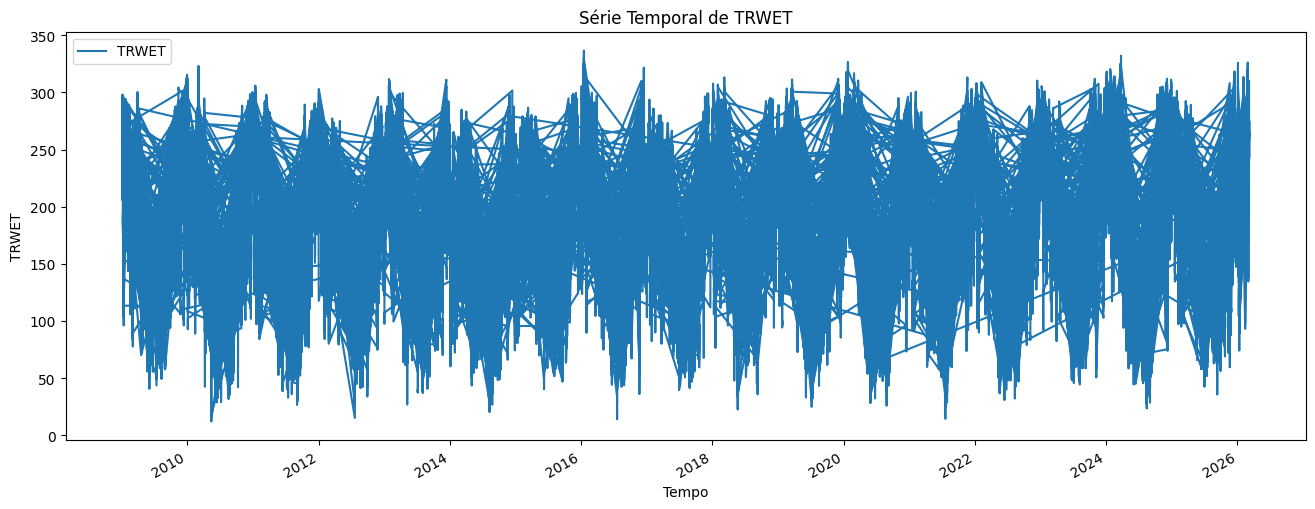

In [ ]:
TRWET.plot(figsize=(16, 6))
plt.title('Série Temporal de TRWET')
plt.xlabel('Tempo')
plt.ylabel('TRWET')
    
plt.show()

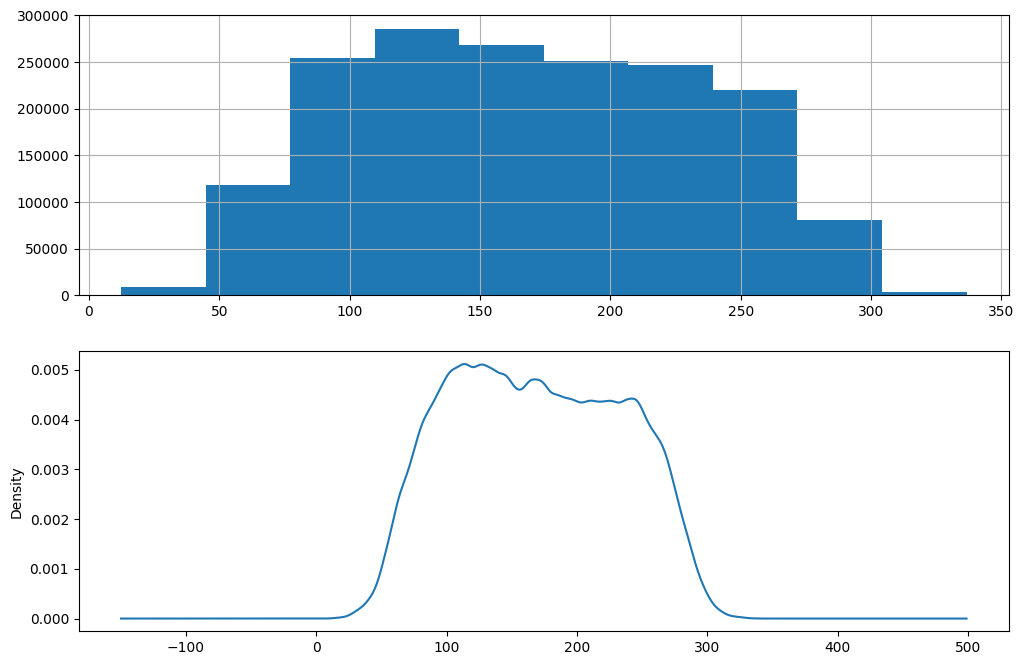

In [55]:
plt.figure(1)
plt.subplot(211)
TRWET.TRWET.hist()


plt.subplot(212)
TRWET.TRWET.plot(kind='kde')

plt.show()

Text(0, 0.5, 'TRWET')

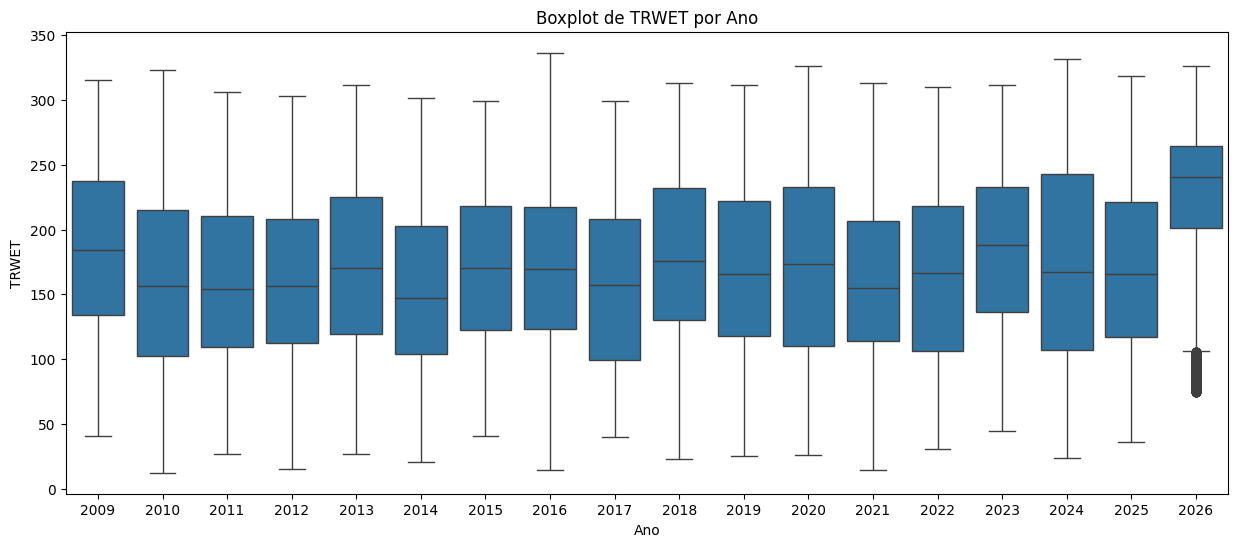

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

indice_ano = TRWET.TRWET.index.year
VALOR = TRWET.TRWET

sns.boxplot(x=indice_ano, y=VALOR, ax=ax, data = TRWET)

plt.title('Boxplot de TRWET por Ano')
plt.xlabel('Ano')
plt.ylabel('TRWET')


## Decomposição Série por coleta

In [57]:
TRWET

,TRWET
data_completa,
2020-03-06 00:00:00,215.7
2020-03-06 00:05:00,216.6
2020-03-06 00:10:00,217.6
2020-03-06 00:15:00,218.8
2020-03-06 00:20:00,219.4
...,...
2012-05-23 23:35:00,116.2
2012-05-23 23:40:00,116.8
2012-05-23 23:45:00,117.3


In [58]:
TRWET_2020 = TRWET[TRWET.index.year == 2020]
TRWET_2020

,TRWET
data_completa,
2020-03-06 00:00:00,215.7
2020-03-06 00:05:00,216.6
2020-03-06 00:10:00,217.6
2020-03-06 00:15:00,218.8
2020-03-06 00:20:00,219.4
...,...
2020-09-05 23:35:00,72.2
2020-09-05 23:40:00,71.0
2020-09-05 23:45:00,70.2


In [59]:
decomposicao_multiplicativa = seasonal_decompose(TRWET_2020, model='multiplicative',extrapolate_trend='freq' ,period=288)

In [60]:
type(decomposicao_multiplicativa)

statsmodels.tsa.seasonal.DecomposeResult

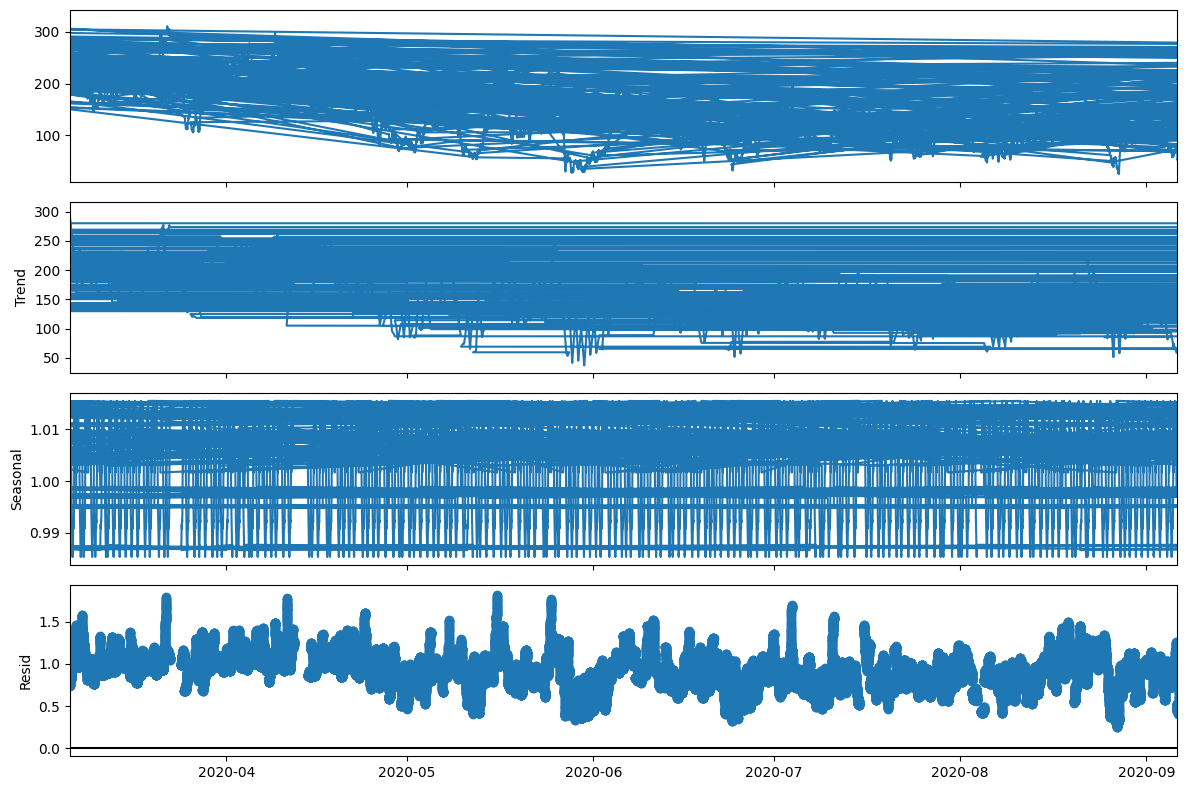

In [61]:
plt.rcParams['figure.figsize'] = (12, 8)
decomposicao_multiplicativa.plot()
plt.show()

In [62]:
decomposicao_aditiva= seasonal_decompose(TRWET_2020, model='additive',extrapolate_trend='freq' ,period=288)

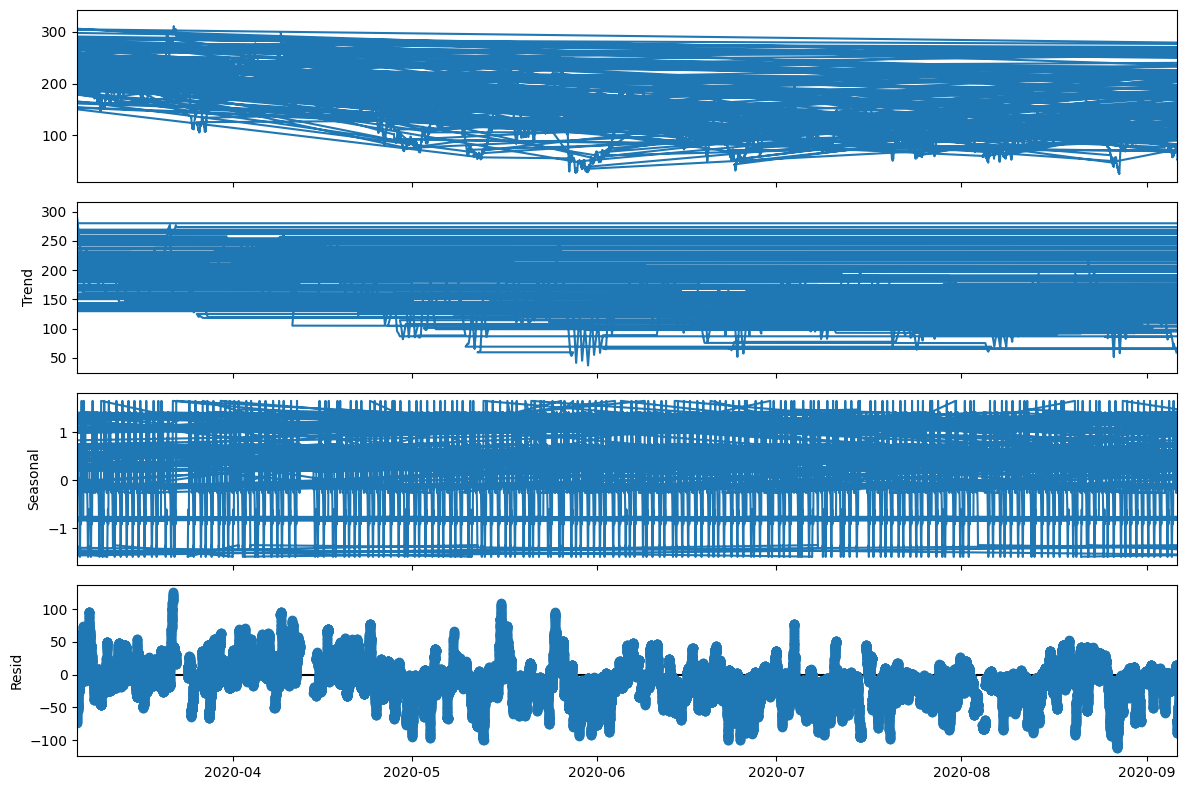

In [63]:
plt.rcParams['figure.figsize'] = (12, 8)
decomposicao_aditiva.plot()
plt.show() 

In [64]:

# 2. Média Diária (resolve duplicatas e ruído)
df_diario = TRWET['TRWET'].resample('D').mean()

# 3. Média Mensal (ex: Jan/2020, Fev/2020...)
df_mensal = df_diario.resample('MS').mean().to_frame()

In [65]:
df_mensal = df_diario.resample('MS').mean().to_frame()

In [66]:
df_mensal

,TRWET
data_completa,
2009-01-01,227.818368
2009-02-01,214.511418
2009-03-01,223.603182
2009-04-01,177.836902
2009-05-01,135.177380
...,...
2025-11-01,186.579443
2025-12-01,223.714528
2026-01-01,220.034722


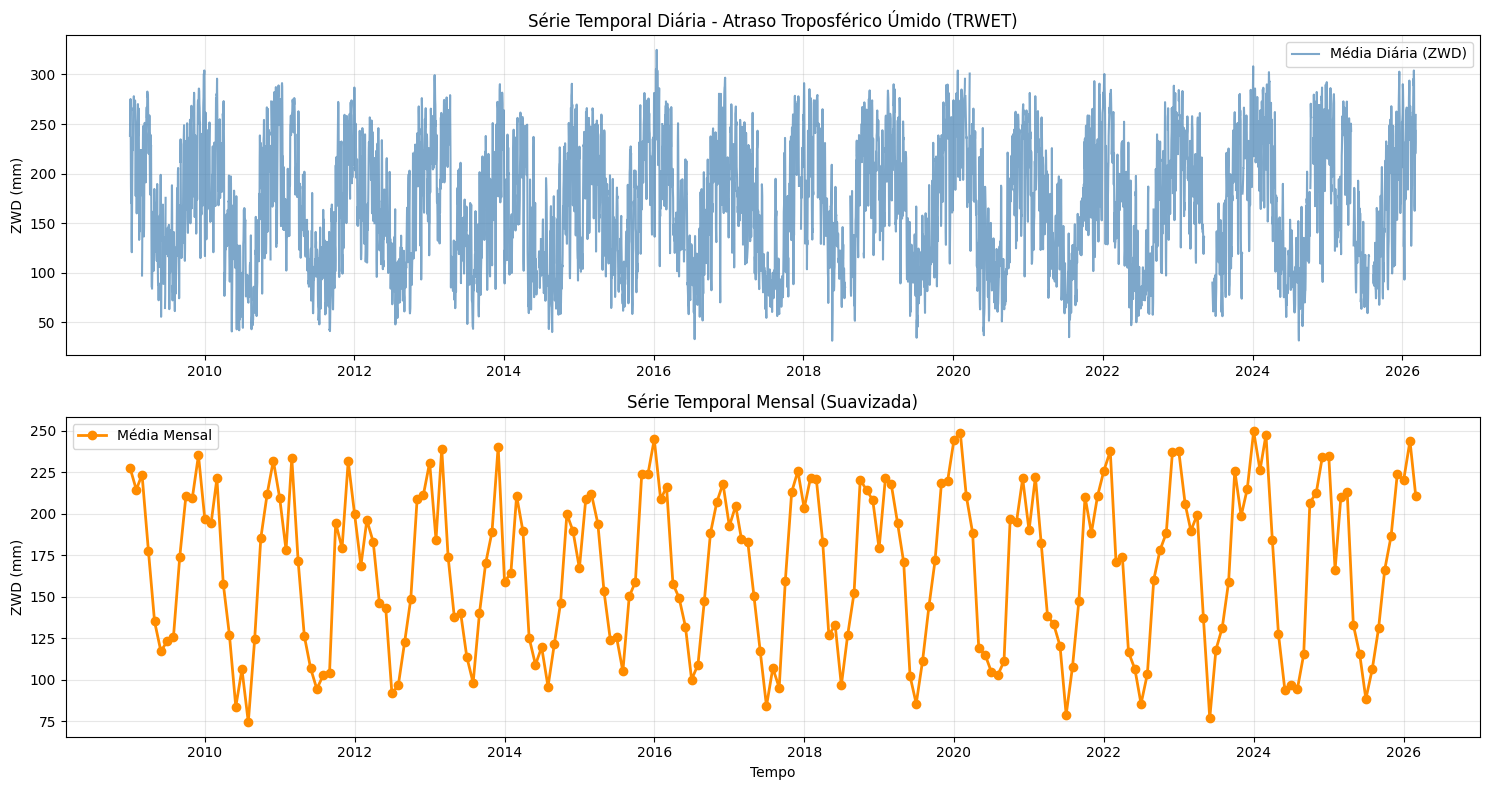

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Média Diária (Agrega os pontos de 5 min e limpa duplicatas/ruído)
# O professor faz isso para ter um valor único por dia (representativo)
TRWET['TRWET'].resample('D').mean()

# 3. Média Mensal (Agrega os dias para ver o comportamento do mês)
# Isso suaviza a série para identificar os padrões sazonais
df_mensal_plot = df_diario.resample('MS').mean()


plt.figure(figsize=(15, 8))

# Gráfico 1: Série Diária (Variabilidade rápida)
plt.subplot(2, 1, 1)
plt.plot(df_diario.index, df_diario.values, color='steelblue', alpha=0.7, label='Média Diária (ZWD)')
plt.title('Série Temporal Diária - Atraso Troposférico Úmido (TRWET)')
plt.ylabel('ZWD (mm)')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: Série Mensal (Tendência e Sazonalidade)
plt.subplot(2, 1, 2)
plt.plot(df_mensal_plot.index, df_mensal_plot.values, color='darkorange', marker='o', linewidth=2, label='Média Mensal')
plt.title('Série Temporal Mensal (Suavizada)')
plt.xlabel('Tempo')
plt.ylabel('ZWD (mm)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [68]:
df_mensal

,TRWET
data_completa,
2009-01-01,227.818368
2009-02-01,214.511418
2009-03-01,223.603182
2009-04-01,177.836902
2009-05-01,135.177380
...,...
2025-11-01,186.579443
2025-12-01,223.714528
2026-01-01,220.034722


In [69]:
decomposicao_aditiva_mensal = seasonal_decompose(df_mensal, model='additive',extrapolate_trend='freq' ,period=12)

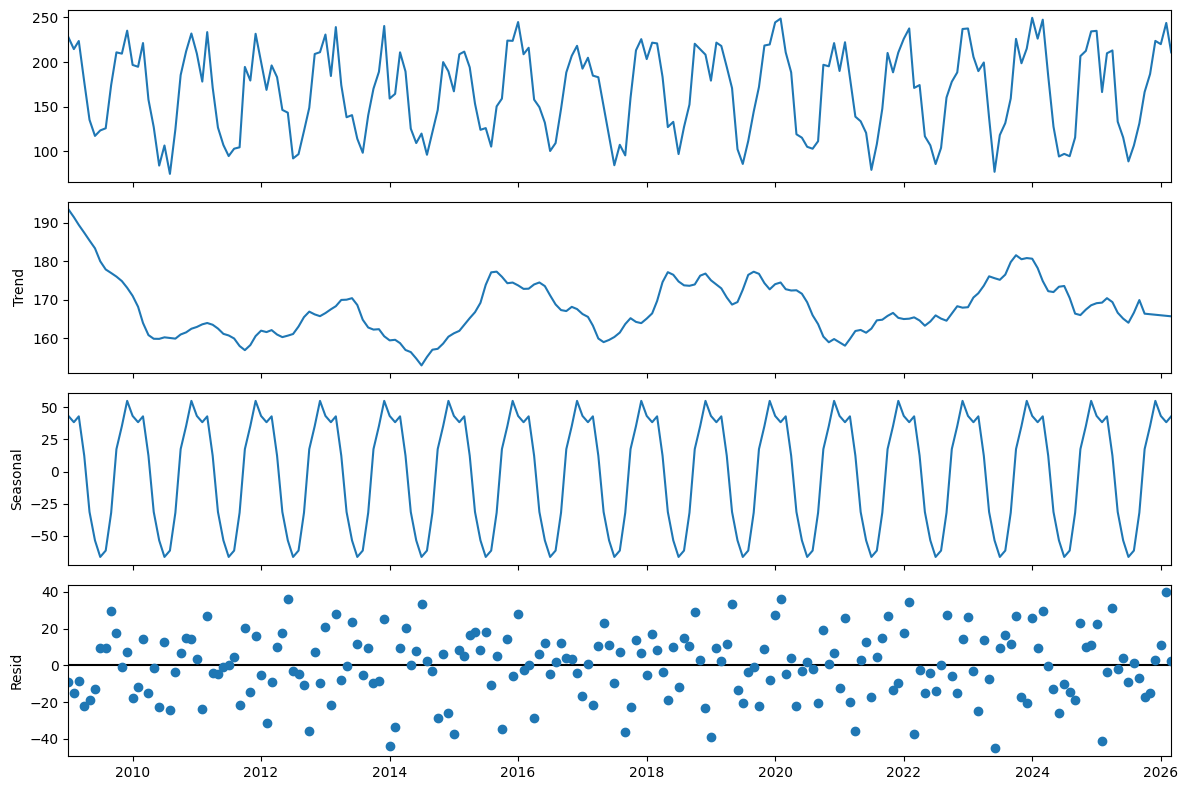

In [70]:
plt.rcParams['figure.figsize'] = (12, 8)
decomposicao_aditiva_mensal.plot()
plt.show() 

In [71]:
df_mensal

,TRWET
data_completa,
2009-01-01,227.818368
2009-02-01,214.511418
2009-03-01,223.603182
2009-04-01,177.836902
2009-05-01,135.177380
...,...
2025-11-01,186.579443
2025-12-01,223.714528
2026-01-01,220.034722


In [72]:

df_diario_preenchido = df_diario.interpolate(method='linear')

# 3. Agora a decomposição vai funcionar
decomposicao_aditiva_diaria = seasonal_decompose(df_diario_preenchido, model='additive', period=365)


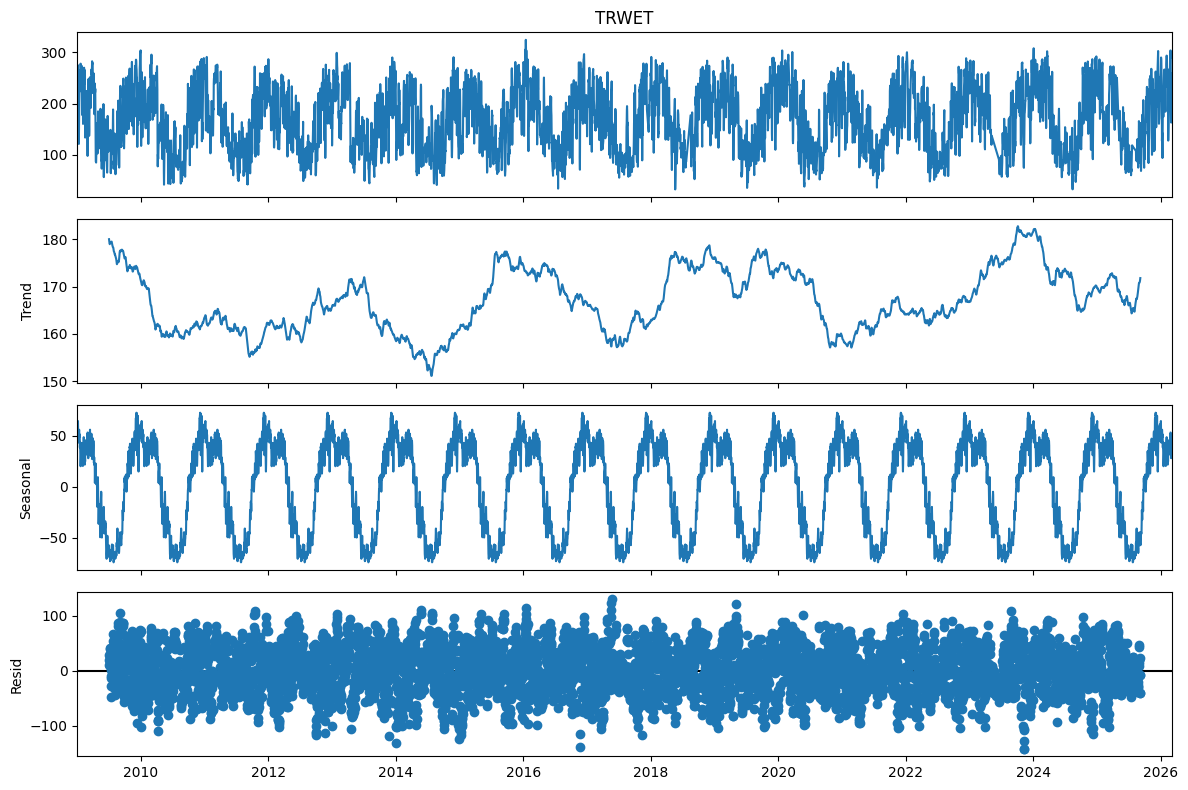

In [73]:
plt.rcParams['figure.figsize'] = (12, 8)
decomposicao_aditiva_diaria.plot()
plt.show() 

In [74]:
# Criar colunas auxiliares de mês e ano
df_mensal['mes'] = df_mensal.index.month
df_mensal['ano'] = df_mensal.index.year

# Calcular a média e o desvio padrão de cada mês do calendário (JAN, FEV...)
climatologia_media = df_mensal.groupby('mes')['TRWET'].mean()
climatologia_std = df_mensal.groupby('mes')['TRWET'].std()

def calcular_zscore(row):
    mes = row['mes']
    media_ref = climatologia_media[mes]
    std_ref = climatologia_std[mes]
    return (row['TRWET'] - media_ref) / std_ref

df_mensal['Zscore_Anomalia'] = df_mensal.apply(calcular_zscore, axis=1)


--- TABELA DE ANOMALIAS MENSAIS (Z-SCORE) ---
                    TRWET  Zscore_Anomalia
data_completa                             
2009-01-01     227.818368         0.580780
2009-02-01     214.511418         0.297429
2009-03-01     223.603182         0.626647
2009-04-01     177.836902        -0.138623
2009-05-01     135.177380        -0.079164
...                   ...              ...
2025-11-01     186.579443        -1.234955
2025-12-01     223.714528         0.116217
2026-01-01     220.034722         0.297294
2026-02-01     243.862388         1.421856
2026-03-01     210.862597        -0.008636

[207 rows x 2 columns]


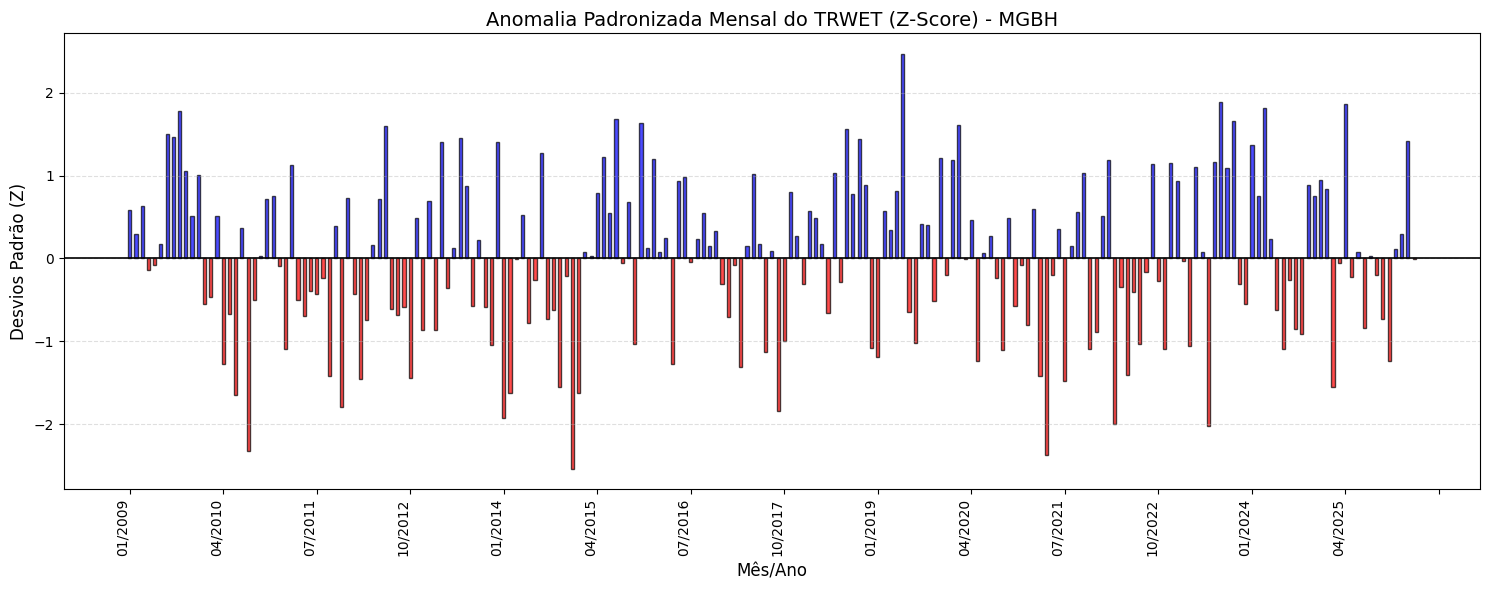

In [75]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- PARTE 1: EXIBIR OS DADOS (PRINT) ---
print("\n--- TABELA DE ANOMALIAS MENSAIS (Z-SCORE) ---")
# Seleciona apenas as colunas relevantes para o print
tabela_print = df_mensal[['TRWET', 'Zscore_Anomalia']]
print(tabela_print)

# --- PARTE 2: GRÁFICO DE BARRAS CORRIGIDO ---
plt.figure(figsize=(15, 6))

# Criamos as cores: Vermelho para seco (negativo), Azul para úmido (positivo)
# fillna(0) evita erro se houver algum mês sem dado
cores = ['red' if x < 0 else 'blue' for x in df_mensal['Zscore_Anomalia'].fillna(0)]

# SOLUÇÃO PARA O ERRO: Converter o índice para string formatada (Ex: "01/2020")
labels_formatados = df_mensal.index.strftime('%m/%Y')

# Usamos plt.bar diretamente (mais robusto que df.plot para esse caso)
plt.bar(labels_formatados, df_mensal['Zscore_Anomalia'], color=cores, width=0.5,edgecolor='black', alpha=0.7)


# Detalhes Estéticos
plt.axhline(0, color='black', linewidth=1.2) # Linha da média
plt.title('Anomalia Padronizada Mensal do TRWET (Z-Score) - MGBH', fontsize=14)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Desvios Padrão (Z)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Rotacionar os meses para caberem no gráfico
plt.xticks(rotation=90, ha='right')

# Se houver muitos anos, podemos pular alguns labels para não poluir
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20)) 

plt.tight_layout()
plt.show()

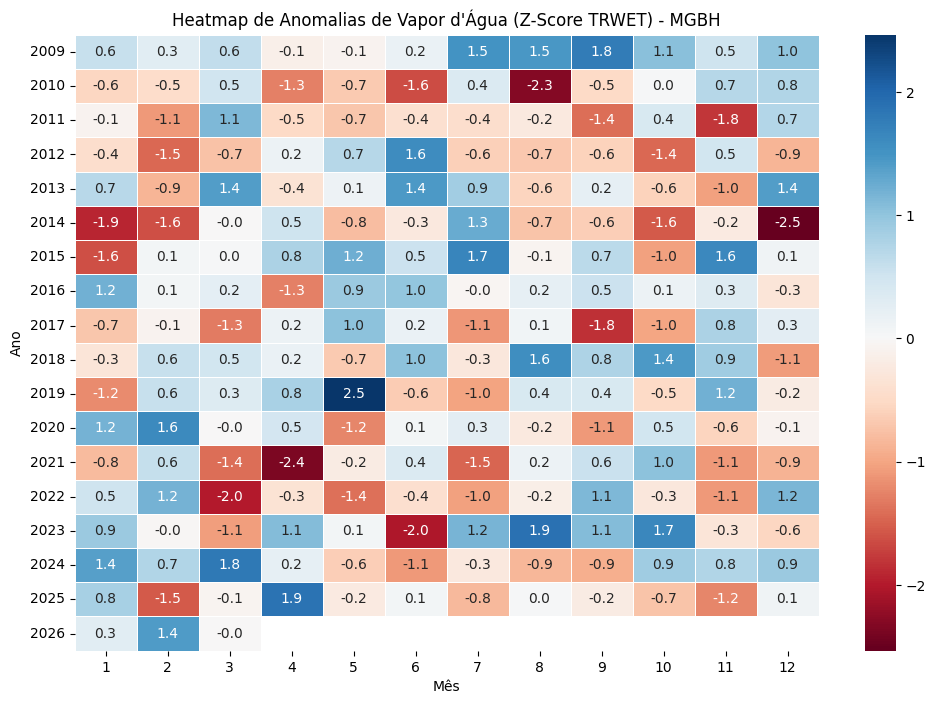

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar a matriz (Anos nas linhas, Meses nas colunas)
mapa_calor = df_mensal.pivot(index='ano', columns='mes', values='Zscore_Anomalia')

# 2. Plotar
plt.figure(figsize=(12, 8))
sns.heatmap(mapa_calor, 
            cmap='RdBu',        # Vermelho (Seco) -> Azul (Úmido)
            center=0,           # Branco é a média exata
            annot=True,         # Mostra o valor de Z dentro do quadrado
            fmt=".1f",          # Uma casa decimal
            linewidths=.5)

plt.title('Heatmap de Anomalias de Vapor d\'Água (Z-Score TRWET) - MGBH')
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.show()

In [79]:
# ==========================================
# 1. TRATAMENTO DOS DADOS INMET (PRECIPITAÇÃO)
# ==========================================
df_inmet = pd.read_csv(r'/home/rafael-luiz/Desktop/IC_gnss/database/dados_inmet/dados.csv')
df_inmet['Data Medicao'] = pd.to_datetime(df_inmet['Data Medicao'])

# Filtrar para Belo Horizonte (Estação MGBH)
df_bh = df_inmet[df_inmet['nome_estacao'] == 'BELO HORIZONTE'].copy()
df_bh.set_index('Data Medicao', inplace=True)

# IMPORTANTE: Para chuva usa-se a SOMA mensal (resample 'MS')
df_prec_mensal = df_bh['PRECIPITACAO TOTAL, DIARIO(mm)'].resample('MS').sum().to_frame()
df_prec_mensal['mes'] = df_prec_mensal.index.month
df_prec_mensal['ano'] = df_prec_mensal.index.year

# Climatologia da Chuva
prec_clima_media = df_prec_mensal.groupby('mes')['PRECIPITACAO TOTAL, DIARIO(mm)'].mean()
prec_clima_std = df_prec_mensal.groupby('mes')['PRECIPITACAO TOTAL, DIARIO(mm)'].std()

# Cálculo do Z-Score da Precipitação
df_prec_mensal['Zscore_Prec'] = df_prec_mensal.apply(
    lambda r: (r['PRECIPITACAO TOTAL, DIARIO(mm)'] - prec_clima_media[r['mes']]) / prec_clima_std[r['mes']], axis=1
)

In [81]:
# ==========================================
# 2. INNER JOIN (CRUZAMENTO COM O TRWET)
# ==========================================

# 1. Garanta que a data_completa seja uma coluna de datetime (caso seja o índice)
# Se 'data_completa' já for uma coluna comum, pode pular a linha do reset_index
df_mensal_reset = df_mensal.reset_index() 

# 2. Criamos as colunas temporárias de ano e mês para o cruzamento
df_mensal_reset['ano'] = df_mensal_reset['data_completa'].dt.year
df_mensal_reset['mes'] = df_mensal_reset['data_completa'].dt.month

# 3. Agora o merge funciona perfeitamente usando as chaves de ano e mês
df_final = pd.merge(
    df_mensal_reset[['ano', 'mes', 'Zscore_Anomalia', 'data_completa']], 
    df_prec_mensal[['ano', 'mes', 'Zscore_Prec']], 
    on=['ano', 'mes'], 
    how='inner'
).dropna()

# 4. Definimos a 'data_completa' original de volta como o índice temporal
df_final.set_index('data_completa', inplace=True)

# 5. Removemos as colunas temporárias para deixar o DataFrame limpo
df_final.drop(columns=['ano', 'mes'], inplace=True)

# Renomeando para facilitar as análises/gráficos
zwd = df_final['Zscore_Anomalia']
prec = df_final['Zscore_Prec']

In [82]:
# ==========================================
# 3. CÁLCULO DAS CORRELAÇÕES
# ==========================================
r_p, p_p = pearsonr(zwd, prec)
r_s, p_s = spearmanr(zwd, prec)

print(f"\n--- CORRELAÇÕES (Pearson e Spearman) ---")
print(f"Pearson:  R = {r_p:.3f} (p-valor = {p_p:.5f})")
print(f"Spearman: R = {r_s:.3f} (p-valor = {p_s:.5f})")


--- CORRELAÇÕES (Pearson e Spearman) ---
Pearson:  R = 0.544 (p-valor = 0.00000)
Spearman: R = 0.570 (p-valor = 0.00000)


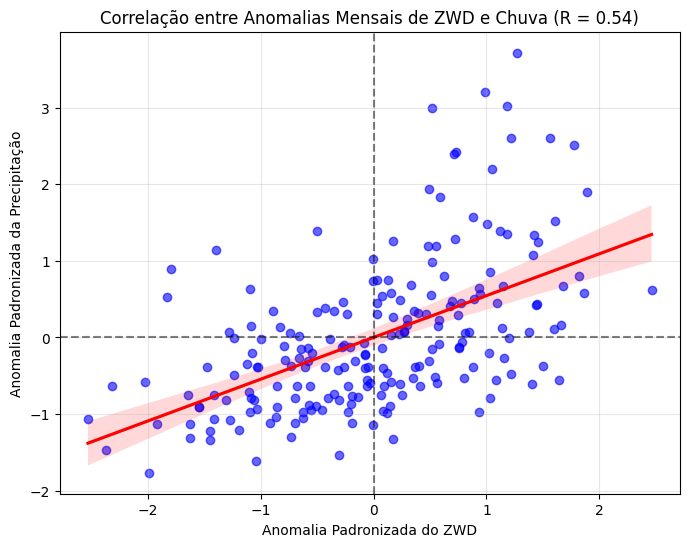

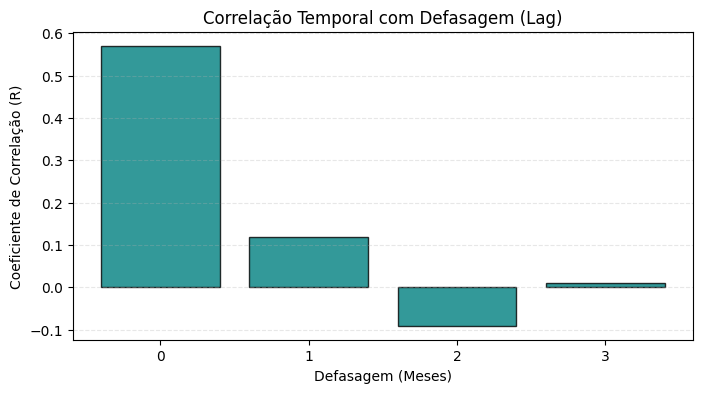

In [85]:
# ==========================================
# 4. GRÁFICOS DE ANÁLISE COMPLEMENTAR
# ==========================================

# Gráfico A: Dispersão com Linha de Tendência
plt.figure(figsize=(8, 6))
sns.regplot(x=zwd, y=prec, scatter_kws={'alpha':0.6, 'color':'blue'}, line_kws={'color':'red'})
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title(f'Correlação entre Anomalias Mensais de ZWD e Chuva (R = {r_p:.2f})')
plt.xlabel('Anomalia Padronizada do ZWD')
plt.ylabel('Anomalia Padronizada da Precipitação')
plt.grid(True, alpha=0.3)
plt.savefig('correlacao_zwd_precipitacao.png')
plt.show()

# Gráfico B: Análise de Defasagem (Lag)
max_lag = 3
lags = range(max_lag + 1)
r_lags = []

for lag in lags:
    if lag == 0:
        r, _ = spearmanr(zwd, prec)
    else:
        r, _ = spearmanr(zwd[:-lag], prec[lag:])
    r_lags.append(r)

plt.figure(figsize=(8, 4))
plt.bar(lags, r_lags, color='teal', edgecolor='black', alpha=0.8)
plt.title('Correlação Temporal com Defasagem (Lag)')
plt.xlabel('Defasagem (Meses)')
plt.ylabel('Coeficiente de Correlação (R)')
plt.xticks(lags)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('correlacao_lag.png')
plt.show()

In [84]:
# ==========================================
# 5. COMPOSITE ANALYSIS (ANÁLISE DE COMPOSTOS)
# ==========================================
bins = [-np.inf, -1, 0, 1, np.inf]
labels = ['ZWD < -1', '-1 <= ZWD < 0', '0 <= ZWD < 1', 'ZWD >= 1']
df_final['Classe_ZWD'] = pd.cut(zwd, bins=bins, labels=labels)

composite = df_final.groupby('Classe_ZWD', observed=False).agg(
    Media_PREC=('Zscore_Prec', 'mean'),
    N_Casos=('Zscore_Prec', 'count'),
    Prob_PREC_Pos=('Zscore_Prec', lambda x: (x > 0).sum() / len(x) * 100)
)

print("\n--- RESULTADO DA COMPOSITE ANALYSIS ---")
print(composite)


--- RESULTADO DA COMPOSITE ANALYSIS ---
               Media_PREC  N_Casos  Prob_PREC_Pos
Classe_ZWD                                       
ZWD < -1        -0.626523       38      15.789474
-1 <= ZWD < 0   -0.408329       63      19.047619
0 <= ZWD < 1     0.279776       70      61.428571
ZWD >= 1         0.836278       36      75.000000


 ---- MATRIZ DE CONFUSÃO MENSAL ----
Total de meses analisados: 207
Sinais concordantes (Acertos): 153
Taxa de concordância geral: 73.9 %

Tabela Cruzada Balanço de Sinais:
col_0    PREC (+)  PREC (-)
row_0                      
ZWD (+)        70        36
ZWD (-)        18        83
----------------------------------------


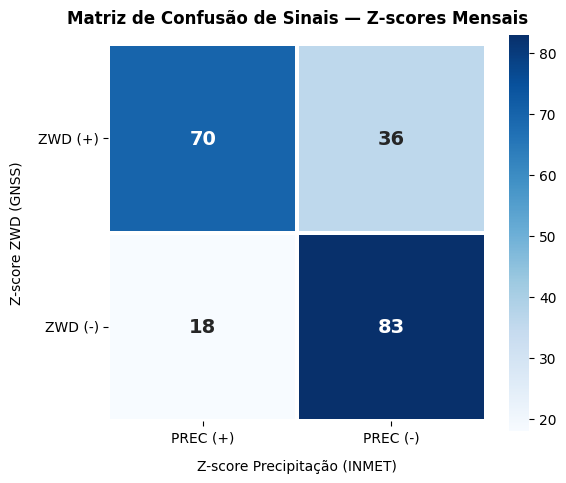

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def gerar_matriz_confusao_sinais(df, col_zwd, col_prec):
    """
    Classifica os Z-scores em positivos (>=0) ou negativos (<0) 
    e constrói a tabela cruzada (matriz de confusão) orientada.
    """
    # Define os sinais baseados nos limites estatísticos de anomalia
    sinal_zwd = np.where(df[col_zwd] >= 0, 'ZWD (+)', 'ZWD (-)')
    sinal_prec = np.where(df[col_prec] >= 0, 'PREC (+)', 'PREC (-)')
    
    # Cria a crosstab (tabela dinâmica de contagem)
    conf_matrix = pd.crosstab(sinal_zwd, sinal_prec)
    
    # Força a ordenação das colunas e linhas para mapear a diagonal de concordância corretamente
    classes_y = ['ZWD (+)', 'ZWD (-)']
    classes_x = ['PREC (+)', 'PREC (-)']
    conf_matrix = conf_matrix.reindex(index=classes_y, columns=classes_x, fill_value=0)
    
    return conf_matrix

# =========================================================
# 1. EXECUÇÃO DOS CÁLCULOS DA MATRIZ
# =========================================================
# Executa a função usando as colunas do seu DataFrame integrado (df_final)
conf_mes = gerar_matriz_confusao_sinais(df_final, "Zscore_Anomalia", "Zscore_Prec")

# Extração de métricas de validação cruzada
total_mes        = int(conf_mes.values.sum())
concordancia_mes = int(np.trace(conf_mes.values)) # Soma a diagonal principal (Acertos)
pct_mes          = concordancia_mes / total_mes * 100 if total_mes else 0

# =========================================================
# 2. EXIBIÇÃO DE MÉTRICAS NO TERMINAL DO NOTEBOOK
# =========================================================
print(" ---- MATRIZ DE CONFUSÃO MENSAL ----")
print(f"Total de meses analisados: {total_mes}")
print(f"Sinais concordantes (Acertos): {concordancia_mes}")
print(f"Taxa de concordância geral: {pct_mes:.1f} %\n")
print("Tabela Cruzada Balanço de Sinais:")
print(conf_mes)
print("-" * 40)

# =========================================================
# 3. CONSTRUÇÃO DO HEATMAP COM SEABORN (SEM DEPENDÊNCIAS DE MIME)
# =========================================================
plt.figure(figsize=(6, 5))

# Criando o mapa de calor usando o Seaborn
sns.heatmap(
    conf_mes, 
    annot=True,          # Mostra os números dentro dos quadrados
    fmt="d",             # Formato de número inteiro (d)
    cmap="Blues",        # Paleta de cores em tons de azul
    linewidths=1.5,      # Linha de separação entre os blocos
    cbar=True,           # Mostra a barra de escala lateral
    square=True,         # Força os blocos a serem quadrados perfeitos
    annot_kws={"size": 14, "weight": "bold"} # Destaca os números internos
)

# Ajustes de títulos e rótulos
plt.title("Matriz de Confusão de Sinais — Z-scores Mensais", fontsize=12, pad=15, weight='bold')
plt.xlabel("Z-score Precipitação (INMET)", fontsize=10, labelpad=10)
plt.ylabel("Z-score ZWD (GNSS)", fontsize=10, labelpad=10)

# Garante que os textos dos eixos fiquem alinhados e sem rotação
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# Salva automaticamente em alta resolução na pasta do projeto
plt.savefig('matriz_confusao_sinais_bh.png', dpi=300) 
plt.show()

/tmp/ipykernel_64810/3001894156.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ano', y='PRECIPITACAO TOTAL, DIARIO(mm)', data=df_prec_mensal, ax=ax, palette="Blues")


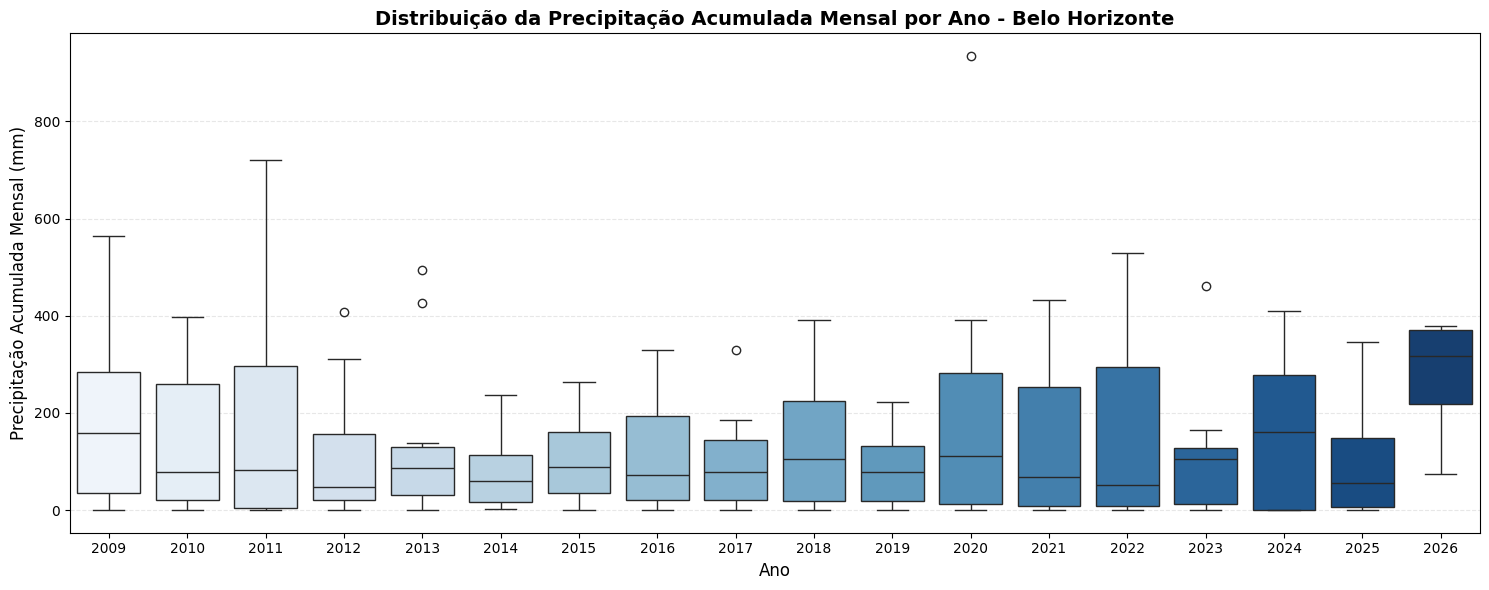

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garantir que temos o acumulado mensal da chuva (criado no Bloco 1 anterior)
df_prec_mensal = df_bh['PRECIPITACAO TOTAL, DIARIO(mm)'].resample('MS').sum().to_frame()
df_prec_mensal['ano'] = df_prec_mensal.index.year

# 2. Configuração do Gráfico
fig, ax = plt.subplots(figsize=(15, 6))

# Criando o Boxplot Anual da Chuva Mensal
sns.boxplot(x='ano', y='PRECIPITACAO TOTAL, DIARIO(mm)', data=df_prec_mensal, ax=ax, palette="Blues")

# Detalhes estéticos
plt.title('Distribuição da Precipitação Acumulada Mensal por Ano - Belo Horizonte', fontsize=14, weight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Precipitação Acumulada Mensal (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_64810/35894812.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=indice_ano_prec, y=VALOR_PREC, ax=ax, palette="Purples")


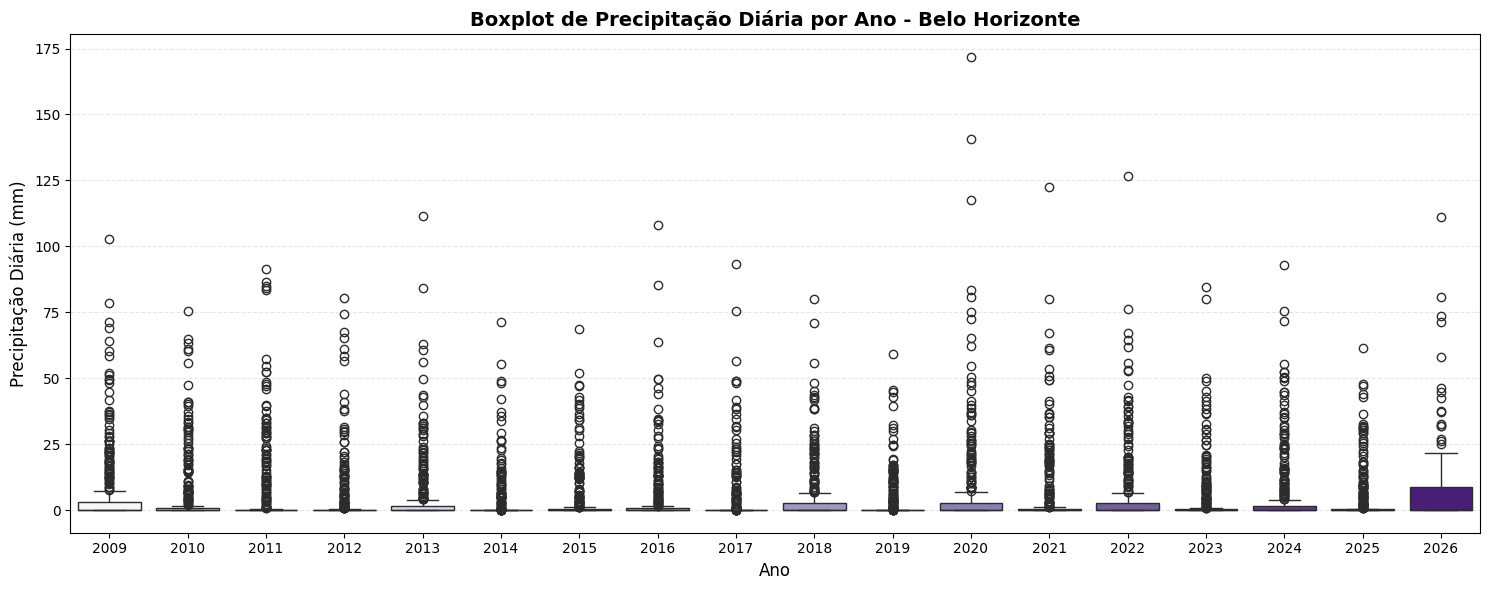

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 6))

# Extrai o ano diretamente do índice dos dados diários do INMET
indice_ano_prec = df_bh.index.year
VALOR_PREC = df_bh['PRECIPITACAO TOTAL, DIARIO(mm)']

# Criando o Boxplot
sns.boxplot(x=indice_ano_prec, y=VALOR_PREC, ax=ax, palette="Purples")

# Detalhes estéticos
plt.title('Boxplot de Precipitação Diária por Ano - Belo Horizonte', fontsize=14, weight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Precipitação Diária (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()